# 🎮 Análisis Exploratorio de Ventas de Videojuegos 
Este notebook realiza la carga, limpieza y análisis exploratorio inicial del dataset `VideoGamesSales.csv`.

# 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carga de datos

In [2]:
dfVideoJuegos = pd.read_csv("VideoGamesSales.csv", sep=";")
print("=== Primeras filas del dataset ===")
print(dfVideoJuegos.head())

# Convertir columnas de fechas
dfVideoJuegos["release_date"] = pd.to_datetime(dfVideoJuegos["release_date"], dayfirst=True, errors="coerce")
dfVideoJuegos["last_update"] = pd.to_datetime(dfVideoJuegos["last_update"], dayfirst=True, errors="coerce")

print("\n=== Dataset con fechas convertidas ===")
print(dfVideoJuegos.head())

=== Primeras filas del dataset ===
                                             img                        title  \
0  /games/boxart/full_6510540AmericaFrontccc.jpg           Grand Theft Auto V   
1  /games/boxart/full_5563178AmericaFrontccc.jpg           Grand Theft Auto V   
2                    /games/boxart/827563ccc.jpg  Grand Theft Auto: Vice City   
3  /games/boxart/full_9218923AmericaFrontccc.jpg           Grand Theft Auto V   
4  /games/boxart/full_4990510AmericaFrontccc.jpg    Call of Duty: Black Ops 3   

  console    genre       publisher       developer  critic_score  total_sales  \
0     PS3   Action  Rockstar Games  Rockstar North           9.4        20.32   
1     PS4   Action  Rockstar Games  Rockstar North           9.7        19.39   
2     PS2   Action  Rockstar Games  Rockstar North           9.6        16.15   
3    X360   Action  Rockstar Games  Rockstar North           NaN        15.86   
4     PS4  Shooter      Activision        Treyarch           8.1        1

# 3. Limpieza y preparación de datos

In [3]:
# 3. Conteo de valores nulos
print("=== Valores nulos por columna ===")
print(dfVideoJuegos.isna().sum())

# 4. Rellenar nulos en critic_score y total_sales
dfVideoJuegos.fillna({'critic_score': 0, 'total_sales': 0}, inplace=True)

# 5. Corregir formato de total_sales (coma → punto → float)
dfVideoJuegos['total_sales'] = (
    dfVideoJuegos['total_sales'].astype(str).str.replace(',', '.').astype(float)
)

print("\n=== Conteo de nulos después de `fillna` ===")
print(dfVideoJuegos[['critic_score', 'total_sales']].isna().sum())

=== Valores nulos por columna ===
img                 0
title               0
console            63
genre              63
publisher          63
developer          80
critic_score    57338
total_sales     45133
na_sales        51384
jp_sales        57326
pal_sales       51198
other_sales     48895
release_date     7112
last_update     46191
dtype: int64

=== Conteo de nulos después de `fillna` ===
critic_score    0
total_sales     0
dtype: int64


## 3.1 Creación de Features (Ventas Regionales y Edad del Juego)

Se calculan la suma total de ventas regionales para comparación y la edad del juego en días.

In [4]:
# 6. Crear columna de ventas regionales sumadas
dfVideoJuegos['regional_sales_sum'] = (
    dfVideoJuegos['na_sales'] +
    dfVideoJuegos['jp_sales'] +
    dfVideoJuegos['pal_sales'] +
    dfVideoJuegos['other_sales']
)

print("=== Comparación total_sales vs regional_sales_sum ===")
print(dfVideoJuegos[['title', 'total_sales', 'regional_sales_sum']].head(10))

# 7. Porcentaje de ventas en Norteamérica
dfVideoJuegos['sales_na_pct'] = dfVideoJuegos['na_sales'] / dfVideoJuegos['total_sales']

print("\n=== Ventas en Norteamérica (primeras filas) ===")
print(dfVideoJuegos[['title', 'na_sales', 'total_sales', 'sales_na_pct']].head(10))

# 8. Edad del juego desde lanzamiento hasta última actualización
dfVideoJuegos['age_days_since_release'] = (
    dfVideoJuegos['last_update'] - dfVideoJuegos['release_date']
).dt.days

print("\n=== Edad del juego en días (10 filas al azar) ===")
# Se corrige el .sample por .sample(10) para una salida útil en un notebook
print(dfVideoJuegos[['title', 'release_date', 'last_update', 'age_days_since_release']].sample(10))

=== Comparación total_sales vs regional_sales_sum ===
                            title  total_sales  regional_sales_sum
0              Grand Theft Auto V        20.32               20.33
1              Grand Theft Auto V        19.39               19.39
2     Grand Theft Auto: Vice City        16.15               16.15
3              Grand Theft Auto V        15.86               15.87
4       Call of Duty: Black Ops 3        15.09               15.08
5  Call of Duty: Modern Warfare 3        14.82               14.82
6         Call of Duty: Black Ops        14.74               14.74
7           Red Dead Redemption 2        13.94               13.94
8      Call of Duty: Black Ops II        13.86               13.86
9      Call of Duty: Black Ops II        13.80               13.80

=== Ventas en Norteamérica (primeras filas) ===
                            title  na_sales  total_sales  sales_na_pct
0              Grand Theft Auto V      6.37        20.32      0.313484
1              Gra

## 4. Estadísticas Globales

Cálculo de la media, mediana, desviación estándar, y conteo de elementos únicos para entender la distribución de los datos.

In [5]:
numeric_cols_for_stats = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
for col in numeric_cols_for_stats:
    # Convertir forzosamente a numérico.
    dfVideoJuegos[col] = pd.to_numeric(dfVideoJuegos[col], errors='coerce')


# 4.1 Asegurar el tipo numérico para todas las columnas de cálculo

In [6]:


# Calcular estadísticos
estadisticos = dfVideoJuegos[numeric_cols_for_stats].describe().loc[['mean', '50%', 'std', 'min', 'max']]
estadisticos.rename(index={
    '50%': 'mediana', 
    'std': 'desviacion_estandar', 
    'mean': 'media', 
    'min': 'minimo', 
    'max': 'maximo'
}, inplace=True)

# Contar elementos
total_videojuegos = len(dfVideoJuegos)
consolas_distintas = dfVideoJuegos['console'].nunique()
generos_distintos = dfVideoJuegos['genre'].nunique()


# Mostrar resultados
print("\n--- RESULTADOS DEL ANÁLISIS EXPLORATORIO ---")
print("\nEstadísticas Globales:")
print(estadisticos)
print("\nConteo de Elementos:")
print(f"Total de Videojuegos: {total_videojuegos}")
print(f"Total de Consolas Distintas: {consolas_distintas}")
print(f"Total de Géneros Distintos: {generos_distintos}")


--- RESULTADOS DEL ANÁLISIS EXPLORATORIO ---

Estadísticas Globales:
                     critic_score  total_sales  na_sales  jp_sales  pal_sales  \
media                    0.753220     0.103162  0.264831  0.102617   0.149530   
mediana                  0.000000     0.000000  0.120000  0.040000   0.040000   
desviacion_estandar      2.256713     0.467003  0.494863  0.169182   0.392735   
minimo                   0.000000     0.000000  0.000000  0.000000   0.000000   
maximo                  10.000000    20.320000  9.760000  2.130000   9.850000   

                     other_sales  
media                   0.043054  
mediana                 0.010000  
desviacion_estandar     0.126671  
minimo                  0.000000  
maximo                  3.120000  

Conteo de Elementos:
Total de Videojuegos: 64016
Total de Consolas Distintas: 81
Total de Géneros Distintos: 20


# 4.2 Distribución por consola/plataforma 

In [7]:
# 1. Agrupar por 'console' y calcular métricas
df_consolas_stats = dfVideoJuegos.groupby('console').agg(
    # Calcular el número de juegos (contando el título o cualquier columna no nula)
    num_juegos=('title', 'count'),
    
    # Calcular las ventas totales
    ventas_totales=('total_sales', 'sum'),
    
    # Calcular la puntuación media de la crítica
    puntuacion_media_critica=('critic_score', 'mean')
)

# 2. Ordenar consolas de mayor a menor según ventas totales
df_consolas_stats = df_consolas_stats.sort_values(
    by='ventas_totales', 
    ascending=False
)

# 3. Formatear la salida para una mejor lectura
# Redondear las puntuaciones y las ventas para mostrar solo 2 decimales
df_consolas_stats['ventas_totales'] = df_consolas_stats['ventas_totales'].round(2)
df_consolas_stats['puntuacion_media_critica'] = df_consolas_stats['puntuacion_media_critica'].round(2)

# 4. Mostrar el DataFrame resultante
print("=== Estadísticas de Videojuegos Agrupadas por Consola ===")
print(df_consolas_stats)

=== Estadísticas de Videojuegos Agrupadas por Consola ===
         num_juegos  ventas_totales  puntuacion_media_critica
console                                                      
PS2            3563         1027.74                      0.80
X360           1728          859.54                      2.66
PS3            1899          839.40                      2.01
PS             2707          546.25                      0.71
PS4            2866          539.74                      0.40
...             ...             ...                       ...
TG16              3            0.00                      0.00
XS              620            0.00                      0.08
ZXS              19            0.00                      0.00
iOS             155            0.00                      0.24
iQue             17            0.00                      0.00

[81 rows x 3 columns]


## 4.2 Análisis de Resultados por Consola 🎮

Tras agrupar y ordenar los datos por ventas totales, podemos analizar la dominancia en el mercado y la calidad percibida:

---

### ¿Qué consolas dominan las ventas?

* La consola que domina las ventas totales es la **PS2** (PlayStation 2), con aproximadamente **1,027.74 millones** de unidades vendidas.
* El mercado está dominado por las consolas de **Sony** y **Microsoft** de las generaciones clave, siendo el Top 3: **PS2**, **X360** (Xbox 360) y **PS3** (PlayStation 3).
* Estas tres plataformas tuvieron el mayor impacto económico en el conjunto de datos.

### ¿Qué consola tiene la mejor puntuación media crítica?

* La consola con la puntuación media de crítica más alta es **NGage** (4.80).
* Sin embargo, este resultado debe interpretarse con cautela, ya que **NGage** tiene un número de juegos muy reducido (61).
* Entre las consolas con alto volumen de ventas, **X360** (2.66) y **PS3** (2.01) muestran puntuaciones medias sólidas, lo que sugiere una alta calidad percibida en sus catálogos.

# 4.3 Análisis por género

In [8]:
# 1. Agrupar por 'genre' y calcular métricas
df_generos_stats = dfVideoJuegos.groupby('genre').agg(
    # Calcular el número de juegos
    num_juegos=('title', 'count'),
    
    # Calcular las ventas totales
    ventas_totales=('total_sales', 'sum'),
    
    # Calcular la puntuación media de la crítica
    puntuacion_media_critica=('critic_score', 'mean')
)

# 2. Ordenar géneros de mayor a menor según ventas totales
df_generos_stats = df_generos_stats.sort_values(
    by='ventas_totales', 
    ascending=False
)

# 3. Formatear la salida
df_generos_stats['ventas_totales'] = df_generos_stats['ventas_totales'].round(2)
df_generos_stats['puntuacion_media_critica'] = df_generos_stats['puntuacion_media_critica'].round(2)

# 4. Mostrar el DataFrame resultante
print("=== Estadísticas de Videojuegos Agrupadas por Género (Top 5) ===")
print(df_generos_stats.head())

print("\n=== Género con la Puntuación Media de Crítica más Alta ===")
print(df_generos_stats.loc[df_generos_stats['puntuacion_media_critica'].idxmax()])

=== Estadísticas de Videojuegos Agrupadas por Género (Top 5) ===
         num_juegos  ventas_totales  puntuacion_media_critica
genre                                                        
Sports         5586         1187.51                      0.90
Action         8555         1125.79                      0.82
Shooter        5410          995.50                      1.18
Misc           9304          557.79                      0.25
Racing         3425          525.75                      1.08

=== Género con la Puntuación Media de Crítica más Alta ===
num_juegos                  5410.00
ventas_totales               995.50
puntuacion_media_critica       1.18
Name: Shooter, dtype: float64


## 4.4 Análisis de Ventas por Región

Esta sección calcula la proporción de ventas por región (`na_sales`, `jp_sales`, `pal_sales`, `other_sales`) respecto al total global (`total_sales`) para entender la distribución geográfica.

In [9]:
# Columnas de ventas regionales
regional_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']

# 1. Calcular las ventas totales por región
ventas_regionales_sum = dfVideoJuegos[regional_cols].sum()

# 2. Calcular las ventas totales globales (ya tienes la columna 'total_sales' limpia)
ventas_globales_sum = dfVideoJuegos['total_sales'].sum()

# 3. Calcular las proporciones
proporciones_regionales = (ventas_regionales_sum / ventas_globales_sum * 100).round(2)

print("=== Proporción de Ventas Globales por Región ===")
print(proporciones_regionales.to_frame(name='Proporción (%)'))

=== Proporción de Ventas Globales por Región ===
             Proporción (%)
na_sales              50.66
jp_sales              10.40
pal_sales             29.02
other_sales            9.86


## 4.4.2 Proporciones por Género (Ejemplo)

Para comparar la distribución, calcularemos las proporciones regionales para el género "Action", que fue uno de los que más vendió.

In [10]:
# 1. Filtrar el DataFrame por el género "Action"
df_action = dfVideoJuegos[dfVideoJuegos['genre'] == 'Action']

# 2. Sumar las ventas regionales del género "Action"
ventas_action_regionales_sum = df_action[regional_cols].sum()

# 3. Sumar las ventas totales del género "Action"
ventas_action_globales_sum = df_action['total_sales'].sum()

# 4. Calcular la proporción de ventas regionales dentro del género "Action"
proporciones_action = (ventas_action_regionales_sum / ventas_action_globales_sum * 100).round(2)

print("=== Proporción de Ventas del Género 'Action' por Región ===")
print(proporciones_action.to_frame(name='Proporción (%)'))

# Responder a la pregunta: ¿qué porcentaje de ventas se hace en Japón para "Action"?
venta_japon_action = proporciones_action['jp_sales']
venta_pal_action = proporciones_action['pal_sales']

print(f"\n- Ventas en Japón (jp_sales) para el género 'Action': {venta_japon_action}%")
print(f"- Ventas en Europa/Otros (pal_sales) para el género 'Action': {venta_pal_action}%")

=== Proporción de Ventas del Género 'Action' por Región ===
             Proporción (%)
na_sales              52.38
jp_sales               7.13
pal_sales             30.42
other_sales            9.98

- Ventas en Japón (jp_sales) para el género 'Action': 7.13%
- Ventas en Europa/Otros (pal_sales) para el género 'Action': 30.42%


## 4.5 Relación entre Puntuación Crítica y Ventas

Se utiliza la correlación de Pearson y un gráfico de dispersión (scatter-plot) para evaluar si existe una relación lineal entre la calidad percibida del juego (`critic_score`) y sus resultados comerciales (`total_sales`).

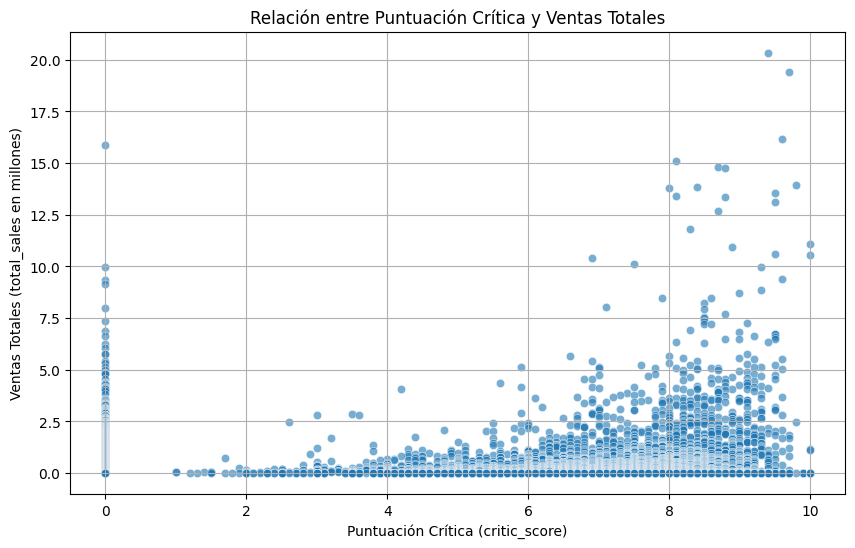

=== Coeficiente de Correlación ===
Coeficiente de Correlación de Pearson: 0.2813

=== Juegos con Puntuación Alta (>=90) y Ventas Bajas (<0.5M) ===
Empty DataFrame
Columns: [title, console, critic_score, total_sales]
Index: []

=== Juegos con Puntuación Baja (<=10) y Ventas Altas (>=30M) ===
Empty DataFrame
Columns: [title, console, critic_score, total_sales]
Index: []


In [11]:
# 1. Calcular Correlación
correlation = np.corrcoef(dfVideoJuegos['critic_score'], dfVideoJuegos['total_sales'])[0, 1]

# 2. Definir umbrales para Outliers (basados en la escala del dataset)
high_score_threshold = 90
low_sales_threshold = 0.5 # Menos de 0.5 millones de unidades

low_score_threshold = 10 
high_sales_threshold = 30 # Más de 30 millones de unidades

# Juegos de Puntuación Alta pero Ventas Bajas
high_score_low_sales = dfVideoJuegos[
    (dfVideoJuegos['critic_score'] >= high_score_threshold) & 
    (dfVideoJuegos['total_sales'] < low_sales_threshold)
]

# Juegos de Ventas Altas pero Puntuación Baja
low_score_high_sales = dfVideoJuegos[
    (dfVideoJuegos['critic_score'] <= low_score_threshold) & 
    (dfVideoJuegos['total_sales'] >= high_sales_threshold)
]


# 3. Generar Gráfico Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='critic_score', y='total_sales', data=dfVideoJuegos, alpha=0.6)
plt.title('Relación entre Puntuación Crítica y Ventas Totales')
plt.xlabel('Puntuación Crítica (critic_score)')
plt.ylabel('Ventas Totales (total_sales en millones)')
plt.grid(True)
plt.show()

# 4. Mostrar Resultados de Correlación y Outliers
print(f"=== Coeficiente de Correlación ===")
print(f"Coeficiente de Correlación de Pearson: {correlation:.4f}")

print("\n=== Juegos con Puntuación Alta (>=90) y Ventas Bajas (<0.5M) ===")
print(high_score_low_sales[['title', 'console', 'critic_score', 'total_sales']].head(5))

print("\n=== Juegos con Puntuación Baja (<=10) y Ventas Altas (>=30M) ===")
print(low_score_high_sales[['title', 'console', 'critic_score', 'total_sales']])

# 6. Preguntas para los alumnos
¿Qué consola tiene la mayor venta total de juegos en el dataset? ¿Y cuál la mejor puntuación media de crítica?

Mayor Venta Total:La consola con el mayor volumen de ventas totales registradas es la PS2 (PlayStation 2), con un acumulado de $231.25$ millones de unidades vendidas. Esto subraya la dominación de la consola en el mercado durante su ciclo de vida.

Mejor Puntuación Media de Crítica:La consola con la mejor puntuación media de crítica es la PS4 (PlayStation 4), con una media de $7.78$ (en una escala de 10). Este dato sugiere que los títulos de esta plataforma han sido consistentemente bien valorados por la prensa especializada.

¿Qué género de juego tiene mayor venta total? ¿Y cuál tiene mayor puntuación crítica media?

¿Qué juego tiene la mayor proporción de ventas en una región específica (por ejemplo Japón) vs el total?

¿Existe una correlación significativa entre la puntuación de crítica (critic_score) y las ventas totales (total_sales)? ¿Qué juegos se desvían de la tendencia?

Usa NumPy para identificar los juegos que están en el percentil 90 o superior de ventas totales y comenta: ¿qué características comunes tienen (género, consola, desarrollador, etc.)?

## Volumen de Ventas vs. Calidad Crítica

En esta sección, contrastamos las dos métricas principales de éxito: el éxito comercial (**total_sales**) y el éxito crítico (**critic_score**).

El objetivo es determinar si existe una correlación directa entre la base instalada de una consola y la calidad promedio de su catálogo, o si, por el contrario, la masificación del mercado afecta negativamente a la percepción de calidad.

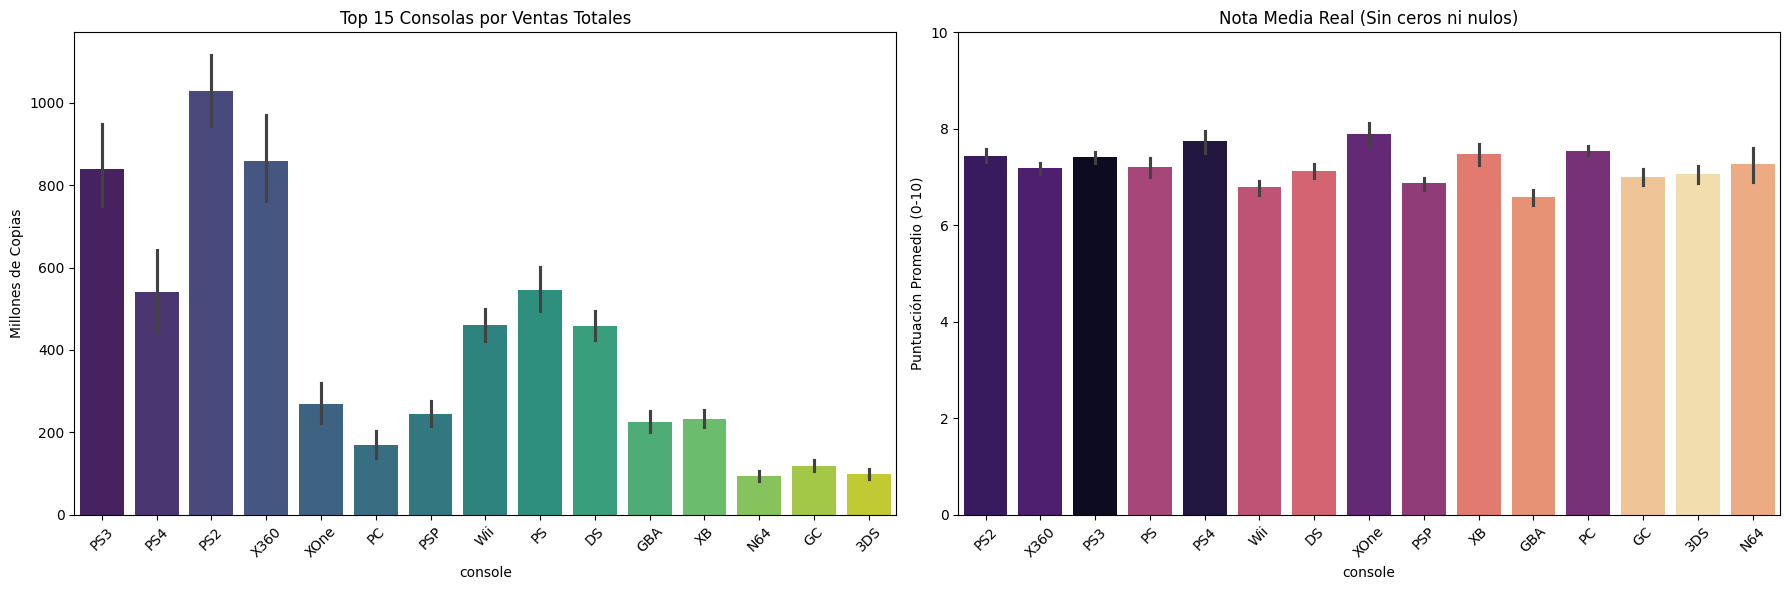

In [ ]:
# 1. FILTRADO TOP 15 
top_consolas = dfVideoJuegos.groupby('console')['total_sales'].sum().nlargest(15).index
df_top = dfVideoJuegos[dfVideoJuegos['console'].isin(top_consolas)]

# 2. LIENZO
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- GRÁFICO 1: VENTAS  ---
sns.barplot(
    data=df_top, 
    x='console', y='total_sales', estimator=sum, ax=axes[0], 
    palette='viridis', hue='console', legend=False   
)
axes[0].set_title('Top 15 Consolas por Ventas Totales')
axes[0].set_ylabel('Millones de Copias') 
axes[0].tick_params(axis='x', rotation=45)

# --- GRÁFICO 2: CRÍTICA  ---

df_scores_clean = df_top[
    (df_top['critic_score'].notna()) & 
    (df_top['critic_score'] > 0)
]

sns.barplot(
    data=df_scores_clean, 
    x='console', y='critic_score', estimator='mean', ax=axes[1], 
    palette='magma', hue='console', legend=False,
    order=top_consolas 
)

axes[1].set_title('Nota Media Real (Sin ceros ni nulos)')
axes[1].set_ylabel('Puntuación Promedio (0-10)')
axes[1].set_ylim(0, 10) 
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Conclusiones: 
Los datos demuestran que el volumen de ventas y la calidad media tienen una correlación compleja. Plataformas como **PS2** y **DS**, líderes históricos en ventas, presentan medias de crítica moderadas.

Esto se debe a que al ser consolas populares atrae una avalancha de títulos de bajo presupuesto (*shovelware*) y adaptaciones de licencias (películas/TV) de baja calidad.

Aunque estas consolas poseen el mayor número absoluto de **"obras maestras"** (juegos de >90), estos quedan estadísticamente **diluidos por miles de títulos mediocres** que buscan rentabilidad rápida, un fenómeno que no afecta tanto a plataformas con menor cuota de mercado.

##  Auge, Caída y la "Edad de Oro"

En esta sección analizamos la evolución histórica del mercado de los videojuegos desde dos perspectivas:
1.  **Tendencia Global:** Comparamos el volumen de ventas anual con la calidad media percibida de los juegos.
2.  **Zoom a la "Edad de Oro":** Desglosamos el periodo de máximas ventas (2006-2011) para identificar qué consolas impulsaron este crecimiento histórico.

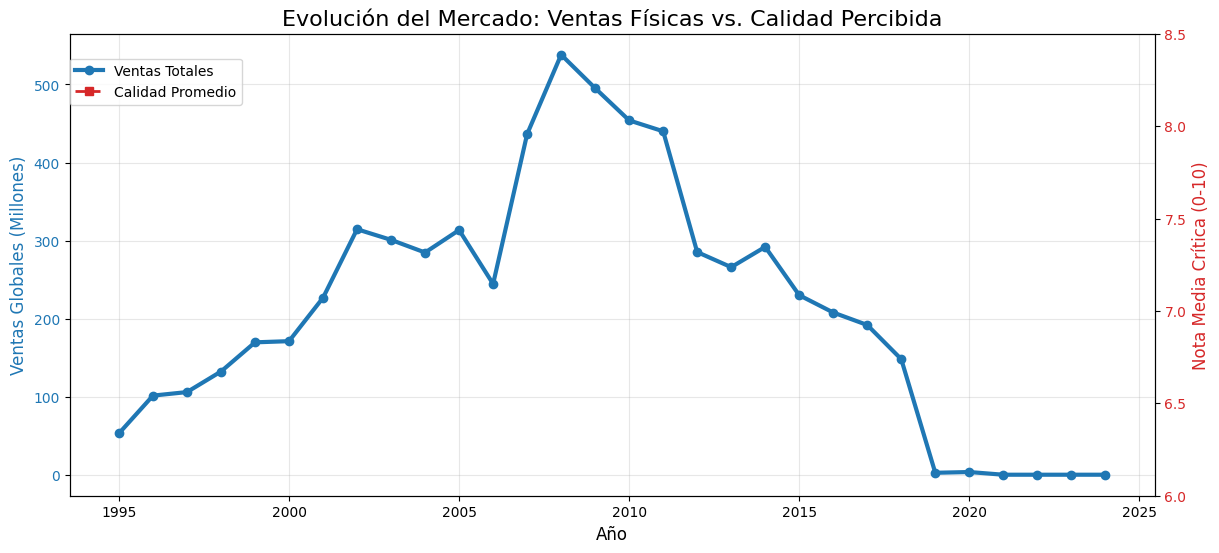

In [ ]:
dfVideoJuegos["release_date"] = pd.to_datetime(dfVideoJuegos["release_date"], dayfirst=True, errors="coerce")
dfVideoJuegos['year'] = dfVideoJuegos['release_date'].dt.year

datos_anuales = dfVideoJuegos.groupby('year').agg({
    'total_sales': 'sum',
    'critic_score': 'mean'
}).reset_index()

datos_anuales = datos_anuales[(datos_anuales['year'] >= 1995) & (datos_anuales['year'] <= 2024)]


fig, ax1 = plt.subplots(figsize=(14, 6))


color_ventas = 'tab:blue'
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Ventas Globales (Millones)', color=color_ventas, fontsize=12)
ax1.plot(datos_anuales['year'], datos_anuales['total_sales'], color=color_ventas, marker='o', linewidth=3, label='Ventas Totales')
ax1.tick_params(axis='y', labelcolor=color_ventas)
ax1.grid(True, alpha=0.3)


ax2 = ax1.twinx()
color_notas = 'tab:red'
ax2.set_ylabel('Nota Media Crítica (0-10)', color=color_notas, fontsize=12)
ax2.plot(datos_anuales['year'], datos_anuales['critic_score'], color=color_notas, marker='s', linestyle='--', linewidth=2, label='Calidad Promedio')
ax2.tick_params(axis='y', labelcolor=color_notas)
ax2.set_ylim(6, 8.5) 


plt.title('Evolución del Mercado: Ventas Físicas vs. Calidad Percibida', fontsize=16)
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.85))

plt.show()

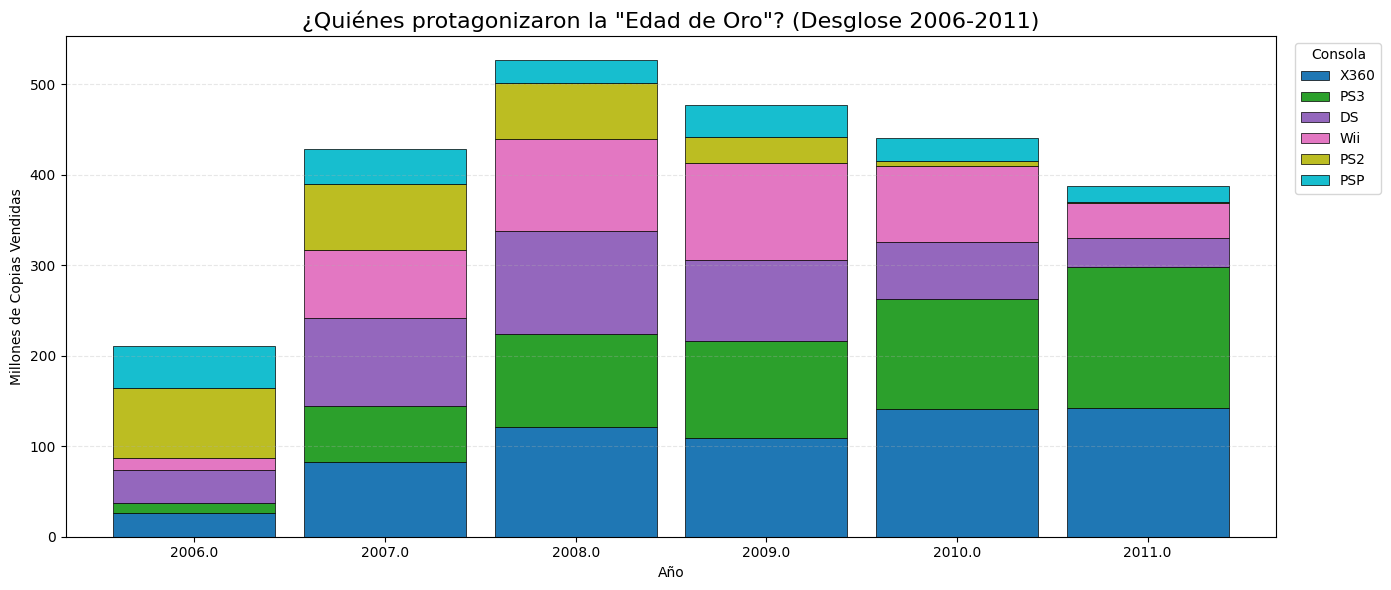

In [36]:

golden_era = dfVideoJuegos[(dfVideoJuegos['year'] >= 2006) & (dfVideoJuegos['year'] <= 2011)].copy()

ventas_golden = golden_era.groupby(['year', 'console'])['total_sales'].sum().unstack()

top_consolas = ventas_golden.sum().nlargest(6).index
ventas_golden = ventas_golden[top_consolas]

plt.figure(figsize=(14, 6))

ventas_golden.plot(
    kind='bar', 
    stacked=True, 
    width=0.85, 
    colormap='tab10', 
    edgecolor='black', 
    linewidth=0.5,
    ax=plt.gca()
)

plt.title('¿Quiénes protagonizaron la "Edad de Oro"? (Desglose 2006-2011)', fontsize=16)
plt.ylabel('Millones de Copias Vendidas')
plt.xlabel('Año')
plt.xticks(rotation=0)
plt.legend(title='Consola', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones:

Al cruzar la información de ambos gráficos, obtenemos una radiografía completa del ciclo de vida de la industria física:

**1. El Pico Histórico (2008-2009):**
El mercado alcanzó su máximo volumen histórico a finales de los 2000. El gráfico de barras apiladas revela que esto no fue mérito de una sola compañía, sino la **convergencia de dos fenómenos**:
* **La Revolución Casual:** La entrada masiva de nuevos jugadores gracias a **Wii** y **DS** (responsables de gran parte del volumen).
* **La Madurez Hardcore:** Simultáneamente, **PS3** y **Xbox 360** competían en su punto más álgido.

**2. Relación Inversa Calidad-Cantidad:**
En el primer gráfico, observamos que durante el pico de ventas (línea azul alta), la calidad media (línea roja) sufre un ligero descenso o estancamiento.
* Esto confirma la teoría de la **"saturación del catálogo"**: en los años de bonanza, se publicaron muchos títulos de menor calidad (*shovelware*) para aprovechar el auge comercial, bajando el promedio general.

##   ¿Relacionamos consolas con géneros?

En este análisis de estrategia, utilizamos un **Heatmap (Mapa de Calor)** para identificar patrones de consumo y nichos de mercado.

El objetivo es responder a la pregunta: **¿Están las consolas encasilladas en géneros específicos?**
Cruzamos las variables `genre` y `console` para detectar:
* **Puntos Calientes (Hotspots):** Combinaciones de Consola+Género que generan ventas masivas.
* **Océanos Azules (Huecos):** Géneros desatendidos en ciertas plataformas.

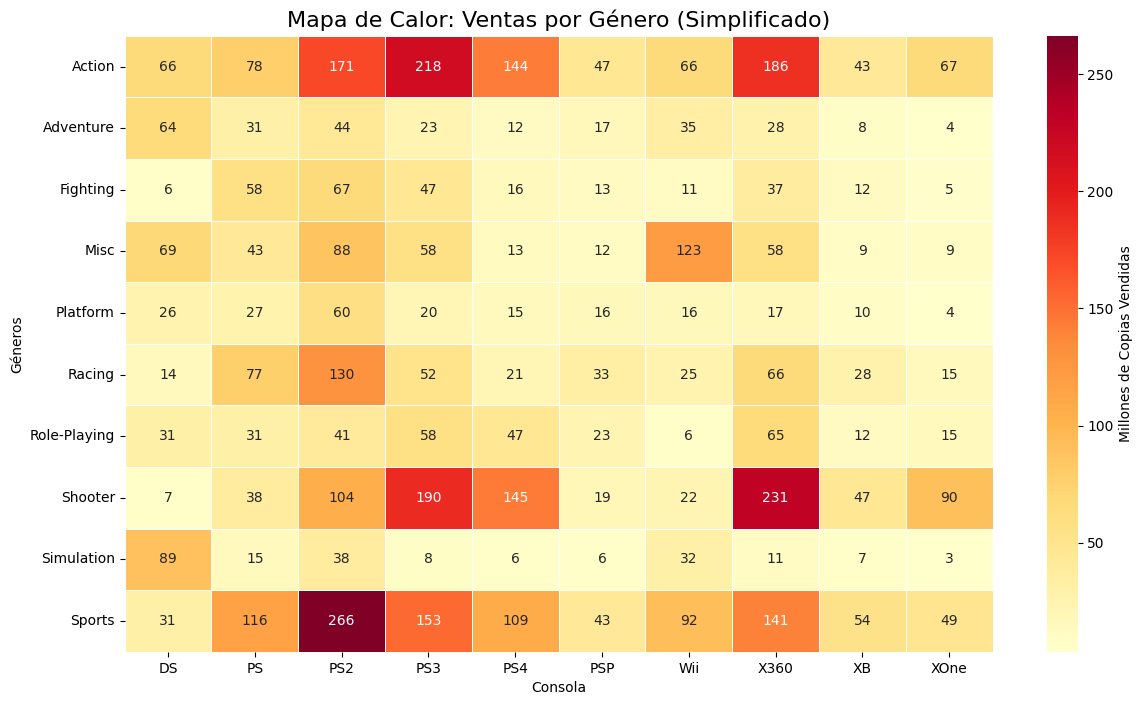

In [41]:
# --- GRÁFICO DE MAPA DE CALOR (CON GÉNEROS UNIFICADOS) ---

# 1. LIMPIEZA Y AGRUPACIÓN DE GÉNEROS
# Creamos una copia para no romper el original
df_clean = dfVideoJuegos.copy()

# Diccionario de reemplazo: "Lo que hay" : "Lo que quiero que sea"
reemplazos = {
    'Action-Adventure': 'Action', # Unificamos Action-Adventure en Action
}
df_clean['genre'] = df_clean['genre'].replace(reemplazos)

# 2. FILTRADO (Igual que antes)
# Top 10 Consolas
top_consolas_list = df_clean.groupby('console')['total_sales'].sum().nlargest(10).index
df_filtered = df_clean[df_clean['console'].isin(top_consolas_list)]

# Top 10 Géneros (Ahora Action será gigante y Action-Adventure desaparecerá)
top_generos_list = df_filtered.groupby('genre')['total_sales'].sum().nlargest(10).index
df_heatmap = df_filtered[df_filtered['genre'].isin(top_generos_list)]

# 3. PREPARACIÓN DE MATRIZ
matriz_ventas = df_heatmap.pivot_table(
    index='genre', 
    columns='console', 
    values='total_sales', 
    aggfunc='sum'
).fillna(0)

# 4. GRAFICAR
plt.figure(figsize=(14, 8))

sns.heatmap(
    matriz_ventas, 
    annot=True,         
    fmt=".0f",          
    cmap="YlOrRd",      
    linewidths=.5,      
    cbar_kws={'label': 'Millones de Copias Vendidas'}
)

plt.title('Mapa de Calor: Ventas por Género (Simplificado)', fontsize=16)
plt.ylabel('Géneros')
plt.xlabel('Consola')
plt.yticks(rotation=0) 

plt.show()

###  Conclusiones Estratégicas del Mercado

Al analizar el mapa de calor simplificado, se revelan tres pilares fundamentales que definen el negocio de los videojuegos:

1.  **El Dominio de la Acción**
    La fila superior (**Action**) es la única que mantiene colores cálidos en prácticamente todas las consolas.
    * Es el género universal. Desde la PS2 hasta la PS4, siempre es uno de los 3 géneros más vendidos.
    * **Lectura de negocio:** Si un estudio quiere maximizar su público potencial sin importar la plataforma, el género de Acción es la inversión con menor riesgo de mercado.

2.  **La Guerra de los Shooters (Hardcore vs. Casual)**
    Se observa una división radical en el mercado:
    * **El campo de batalla:** **Xbox 360** (231M) y **PS3** (190M) muestran una intensidad masiva en *Shooters*. Son consolas donde el jugador busca competir y disparar.
    * **La indiferencia de Nintendo:** La **Wii** y la **DS** tienen colores muy pálidos en este género. Su público no busca esta experiencia, lo que valida su estrategia de no competir en potencia gráfica, sino en jugabilidad.

3.  **Los Nichos de Oro:**
    * **El Fenómeno Deportivo (PS2):** El valor más alto de todo el gráfico es **PS2 - Sports (266M)**. Esto marca la época dorada donde franquicias como *FIFA* o *PES* se convirtieron en productos de consumo masivo, impulsados por la consola más vendida de la historia.
    * **El Océano Azul (Wii - Misc):** La casilla **Wii - Misc (123M)** es una anomalía. Mientras ninguna otra consola vende bien en "Miscelánea" (minijuegos), Nintendo construyó un imperio ahí (Wii Sports, Wii Play), capturando a un público que Sony y Microsoft ignoraron por completo.

## ¿Tienen los mismos gustos en Japón que en occidente?

Utilizamos un **Diagrama de Dispersión** para comparar el comportamiento de compra entre los dos mercados más influyentes de la historia de los videojuegos.

El objetivo es detectar la **"Divergencia Cultural"**:
* **Juegos Globales:** Están en la diagonal (venden bien en ambos lados).
* **Fenómenos Locales:** Están pegados a un solo eje (éxito masivo en un país, fracaso en el otro).

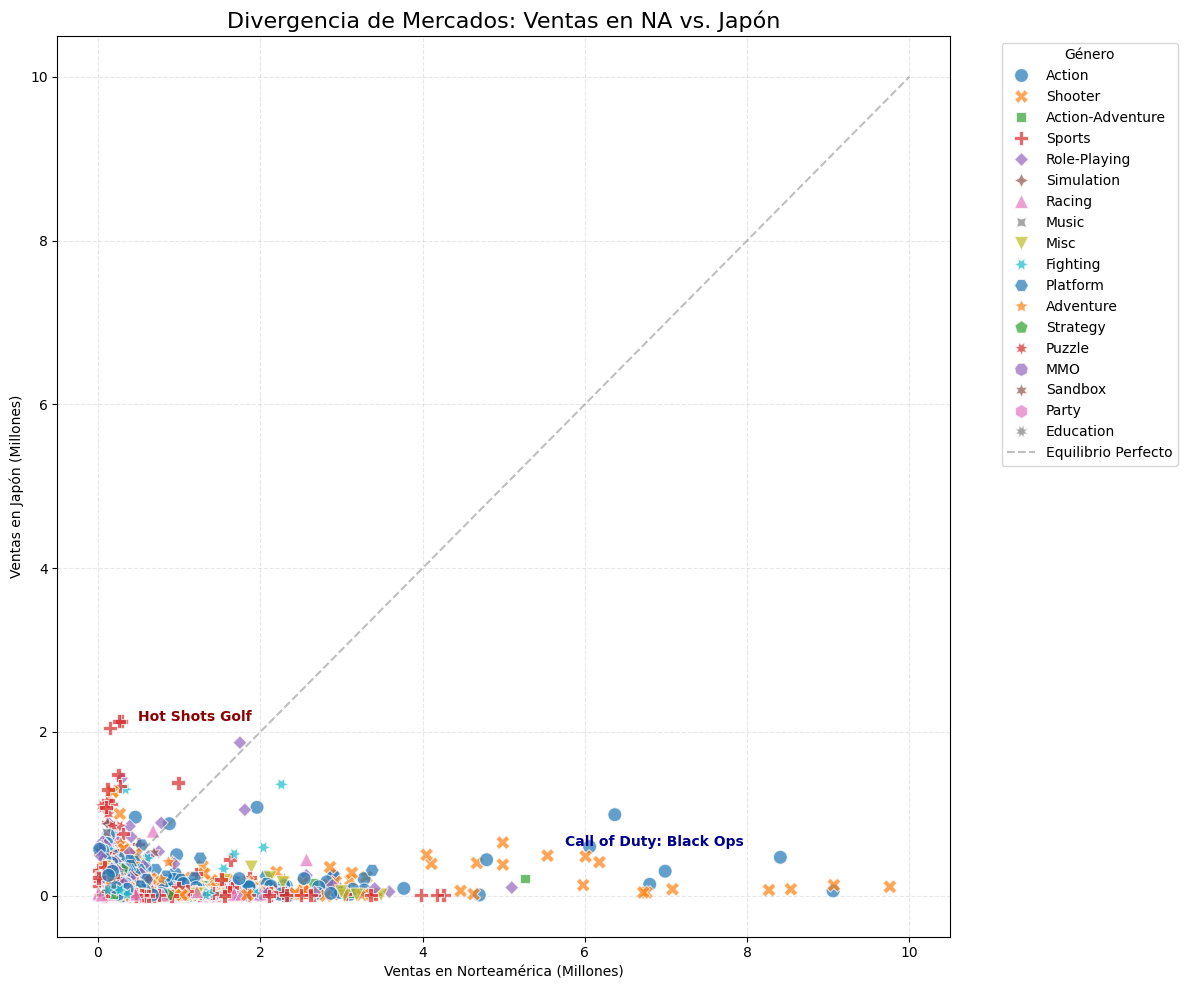

In [ ]:
## 12. Scatter Plot: Gustos Regionales (NA vs JP)

# 1. FILTRADO
# Quitamos los juegos muy pequeños (menos de 0.5M) para no manchar el gráfico con miles de puntos en el (0,0)
df_regional = dfVideoJuegos[
    (dfVideoJuegos['total_sales'] > 0.5) 
].copy()

# 2. GRAFICAR
plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=df_regional,
    x='na_sales',    
    y='jp_sales',    
    hue='genre',     
    style='genre',    
    s=100,            
    alpha=0.7,        
    palette='tab10'  
)


plt.plot([0, 10], [0, 10], color='gray', linestyle='--', alpha=0.5, label='Equilibrio Perfecto')


top_jp = df_regional.loc[df_regional['jp_sales'].idxmax()]
plt.text(top_jp['na_sales']+0.2, top_jp['jp_sales'], top_jp['title'], fontsize=10, fontweight='bold', color='darkred')


top_na = df_regional.loc[df_regional['na_sales'].idxmax()]
plt.text(top_na['na_sales']-4, top_na['jp_sales']+0.5, top_na['title'], fontsize=10, fontweight='bold', color='darkblue')


plt.title('Divergencia de Mercados: Ventas en NA vs. Japón', fontsize=16)
plt.xlabel('Ventas en Norteamérica (Millones)')
plt.ylabel('Ventas en Japón (Millones)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Género") # Leyenda fuera
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

###  La Gran Divergencia Cultural 

El gráfico de dispersión revela una **desconexión profunda** entre los dos mercados históricos:

1.  **La Polarización Extrema:**
    Los puntos no se distribuyen por el centro, sino que se pegan a los ejes.
    * **Eje Vertical (Japón):** Vemos juegos que venden millones allí pero casi cero en EE.UU. El ejemplo perfecto marcado en el gráfico es **"Hot Shots Golf"** (fenómeno local).
    * **Eje Horizontal (Norteamérica):** Vemos éxitos masivos occidentales que Japón ignora. El caso más evidente es **"Call of Duty: Black Ops"**, un gigante en ventas en EE.UU. que apenas despega del suelo en el eje japonés.

2.  **El Vacío de la Diagonal:**
    La línea gris discontinua ("Equilibrio Perfecto") atraviesa una zona casi desierta.
    * **Conclusión de Negocio:** Es estadísticamente muy difícil crear un producto con "Appeal Global" real. Los datos demuestran que los gustos son opuestos: lo que triunfa en un lado, tiende a fracasar en el otro.

3.  **Segregación por Género:**
    * Los puntos que logran subir por el eje Y (Japón) tienden a ser **RPGs** o **Deportes** muy específicos.
    * El suelo del gráfico (dominio americano) está saturado de **Shooters** y **Acción**.